<a href="https://colab.research.google.com/github/adrian-dgx25/E-Commerce-Project-A-B-Testing/blob/main/Project_Data_Enthusiast_A_B_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math

**LOADING & EXPLORING THE DATASET**

**# EDA Dataset 1: Menu**

In [14]:
# 1. test 1 Menu

df_1 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSm_1J4LTLIg_nsdmmiajMNOHSfEIFoIK9aDKydcyT2Bx9MVIPx-7bv4cuuj3tzNlbXMNcVloLAgmUm/pub?output=csv"
df_1 = pd.read_csv(df_1)
df_1.head()

,session_id,user_id,timestamp,device_type,browser,region,variant,pages_viewed,added_to_cart,bounced,revenue
0,sess_000000,user_001861,2021-03-07,desktop,Safari,Osijek,A_horizontal_menu,2.299070,1,1,2.767615
1,sess_000001,user_001205,2021-03-04,mobile,Chrome,Other,A_horizontal_menu,2.071886,1,0,2.354004
2,sess_000002,user_000685,2021-03-05,desktop,Chrome,Rijeka,A_horizontal_menu,3.159581,1,0,0.547931
3,sess_000003,user_001851,2021-03-07,desktop,Chrome,Split,A_horizontal_menu,2.568082,1,0,5.348691
4,sess_000004,user_000187,2021-03-03,mobile,Chrome,Split,A_horizontal_menu,1.433892,1,0,2.790300


In [15]:
# df_1 Dataset Checking

df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   session_id     7000 non-null   object 
 1   user_id        7000 non-null   object 
 2   timestamp      7000 non-null   object 
 3   device_type    7000 non-null   object 
 4   browser        7000 non-null   object 
 5   region         7000 non-null   object 
 6   variant        7000 non-null   object 
 7   pages_viewed   7000 non-null   float64
 8   added_to_cart  7000 non-null   int64  
 9   bounced        7000 non-null   int64  
 10  revenue        7000 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 601.7+ KB


In [16]:
# df_1 Dataset Statistical Summary

df_1.describe()

,pages_viewed,added_to_cart,bounced,revenue
count,7000.000000,7000.000000,7000.000000,7000.000000
mean,2.172393,0.912000,0.439714,3.310906
std,0.741193,0.283315,0.496388,2.407426
min,1.000000,0.000000,0.000000,0.023766
25%,1.616621,1.000000,0.000000,1.579582
50%,2.148767,1.000000,0.000000,2.733476
75%,2.674441,1.000000,1.000000,4.399575
max,5.217332,1.000000,1.000000,20.106859


In [17]:
# df_1 unique region

df_1.region.unique()

array(['Osijek', 'Other', 'Rijeka', 'Split', 'Zagreb'], dtype=object)

/tmp/ipython-input-1204422853.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='browser', y='revenue', data=df_1, estimator=sum, errorbar=None, palette='viridis')


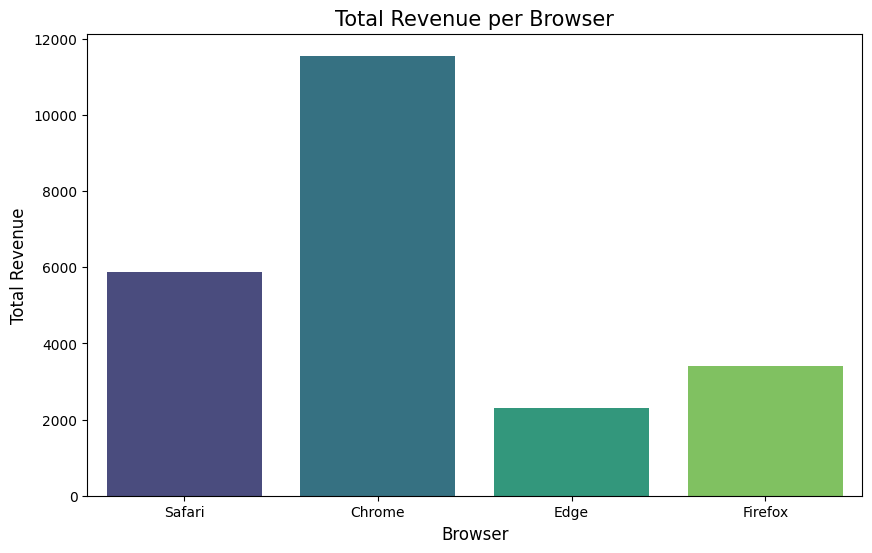

In [18]:
# Revenue per Browser

# Setup ukuran canvas
plt.figure(figsize=(10, 6))

# Setup Bar Plot
sns.barplot(x='browser', y='revenue', data=df_1, estimator=sum, errorbar=None, palette='viridis')

# Setup Interface
plt.title('Total Revenue per Browser', fontsize=15)
plt.xlabel('Browser', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

plt.show()

/tmp/ipython-input-1463598171.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='region', y='revenue', data=df_1, estimator=sum, errorbar=None, palette='viridis')


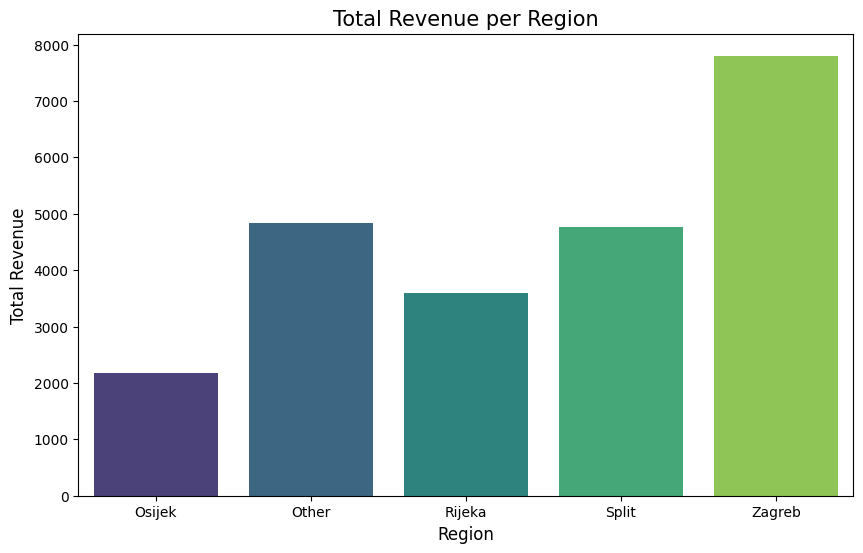

In [19]:
# Revenue per Region

# Setup ukuran canvas
plt.figure(figsize=(10, 6))

# Setup Bar Plot
sns.barplot(x='region', y='revenue', data=df_1, estimator=sum, errorbar=None, palette='viridis')

# Setup Interface
plt.title('Total Revenue per Region', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

plt.show()

/tmp/ipython-input-2625429095.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='variant', y='revenue', data=df_1, estimator=sum, errorbar=None, palette='viridis')


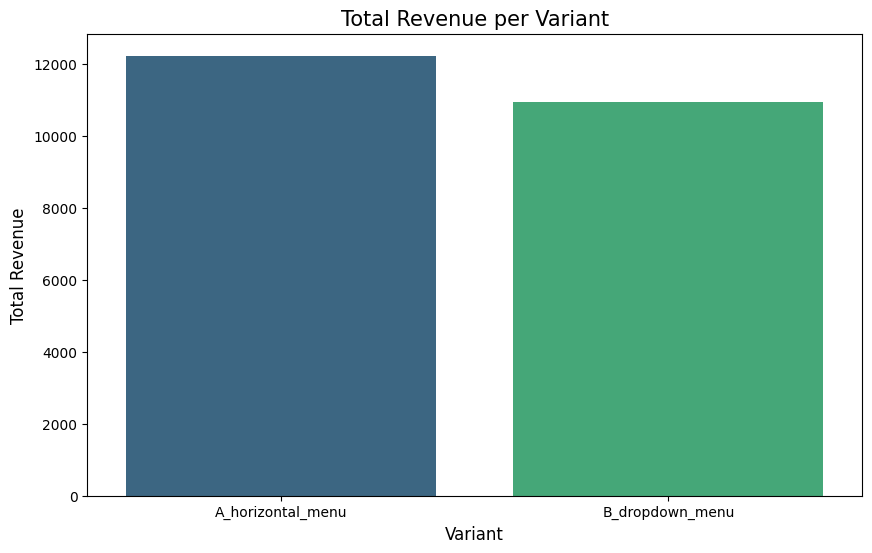

In [20]:
# Revenue per Variant

# Setup ukuran canvas
plt.figure(figsize=(10, 6))

# Setup Bar Plot
sns.barplot(x='variant', y='revenue', data=df_1, estimator=sum, errorbar=None, palette='viridis')

# Setup Interface
plt.title('Total Revenue per Variant', fontsize=15)
plt.xlabel('Variant', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

plt.show()

**# EDA Dataset 2: Novelty Slider**

In [21]:
# 2. test 2 Novelty Slider

df_2 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRLikq1XV_AUah-6PemT_TajvI9sf-g5qs-Hq6RY2zNjnXJ2u29KquizPc8_T91H1FxccuLl_gyyNvX/pub?output=csv"
df_2 = pd.read_csv(df_2)
df_2.head()

,session_id,user_id,timestamp,device_type,browser,region,variant,is_registered,novelty_revenue,products_added_from_novelties
0,sess_000000,user_003937,2021-03-13,desktop,Chrome,Zagreb,A_manual_novelties,1,6.611739,0
1,sess_000001,user_005445,2021-03-18,mobile,Safari,Rijeka,A_manual_novelties,1,2.508166,0
2,sess_000002,user_001121,2021-03-13,mobile,Chrome,Zagreb,A_manual_novelties,1,3.860873,0
3,sess_000003,user_002155,2021-03-19,mobile,Safari,Split,A_manual_novelties,1,5.869096,0
4,sess_000004,user_000349,2021-03-15,tablet,Firefox,Zagreb,A_manual_novelties,0,1.404599,0


In [22]:
# 3. test 3 Product Slider

df_3 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQaL4Q_xQFh_f5PLX9IHn9cbm4N5flmeUdC0X5JwaExIgiMzHIp96o5DSbjMLmsmBgu5uzvebQgpcqK/pub?output=csv"
df_3 = pd.read_csv(df_3)
df_3.head()

,session_id,user_id,timestamp,device_type,browser,region,variant,add_to_cart_rate,slider_interactions,revenue_from_recommendations,products_per_order,avg_product_price
0,sess_000000,user_000567,2021-03-31,mobile,Firefox,Zagreb,A_selected_by_others_only,0,1,3.471560,3.096859,3.284346
1,sess_000001,user_002296,2021-03-28,desktop,Safari,Zagreb,A_selected_by_others_only,0,4,2.661356,3.533376,3.617489
2,sess_000002,user_002093,2021-04-05,desktop,Safari,Rijeka,A_selected_by_others_only,0,2,1.171862,2.662017,4.786812
3,sess_000003,user_003489,2021-04-03,desktop,Safari,Osijek,A_selected_by_others_only,0,2,4.125438,3.888011,5.257324
4,sess_000004,user_000446,2021-03-29,desktop,Chrome,Split,A_selected_by_others_only,0,2,1.884486,2.126060,3.966839


In [23]:
# 4. test 4 Reviews

df_4 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vT_mLCi9X9wGe69Apmy17q4sp9D_TJuNfpGScspVSlO33v6MO16_IV5VSYwjDehBumdV4ZJHLV_YA8Y/pub?output=csv"
df_4 = pd.read_csv(df_4)
df_4.head()

,session_id,user_id,timestamp,device_type,browser,region,variant,converted,added_to_cart
0,sess_000000,user_001127,2021-04-11,mobile,Chrome,Other,A_no_featured_reviews,0,1
1,sess_000001,user_006812,2021-05-02,mobile,Chrome,Rijeka,A_no_featured_reviews,0,1
2,sess_000002,user_004380,2021-04-27,mobile,Chrome,Zagreb,A_no_featured_reviews,0,1
3,sess_000003,user_009545,2021-04-29,mobile,Chrome,Zagreb,A_no_featured_reviews,0,1
4,sess_000004,user_012102,2021-05-08,mobile,Chrome,Other,A_no_featured_reviews,0,1


In [24]:
# 5. test 5 Search Engine

df_5 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQBu1u_osV_ZKMC6Cl67VHuttXeRxEHXgXuu5xcUz1mwCIGwbbRVQXBpX8F0ZtOiWLu3ligU0gBkn7w/pub?output=csv"
df_5 = pd.read_csv(df_5)
df_5.head()

,session_id,user_id,timestamp,device_type,browser,region,variant,avg_revenue_per_visitor,added_to_cart,converted,interacted_with_search
0,sess_000000,user_001321,2021-06-13,desktop,Chrome,Other,A_hybris_search,1.066146,1,0,0
1,sess_000001,user_000722,2021-06-17,mobile,Safari,Split,A_hybris_search,0.817668,1,0,0
2,sess_000002,user_000665,2021-06-14,mobile,Chrome,Zagreb,A_hybris_search,1.341627,1,0,1
3,sess_000003,user_002173,2021-06-14,desktop,Chrome,Other,A_hybris_search,1.389355,1,0,1
4,sess_000004,user_001023,2021-06-13,desktop,Chrome,Other,A_hybris_search,0.285824,1,0,0
